## Load training gradients and query gradients

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
import os

In [3]:
from pathlib import Path
import shutil

# NFS source (slow)
save_dir_train_nfs = Path("tmp/wikitext_cache_train_605dc977").resolve()
# save_dir_train_nfs = Path("/tmp/wikitext_cache_train_605dc977").resolve()
proj_dim = 32

# Local (fast) cache on the compute node
_tmp_root = Path("/tmp") / os.environ.get("USER", "user") / "grad_logs_cache"
save_dir_train = _tmp_root / save_dir_train_nfs.name


def _sync_directories(src: Path, dst: Path) -> int:
    """Sync src to dst, copying new/updated files and removing stale ones.
    
    Returns the number of files copied.
    """
    dst.mkdir(parents=True, exist_ok=True)
    
    # Get all relative paths in source and destination
    src_files = {p.relative_to(src) for p in src.rglob("*") if p.is_file()}
    dst_files = {p.relative_to(dst) for p in dst.rglob("*") if p.is_file()}
    
    # # Remove files in dst that don't exist in src
    # for rel_path in dst_files - src_files:
    #     (dst / rel_path).unlink()
    
    # # Remove empty directories in dst
    # for d in sorted((dst / rel_path).parent for rel_path in dst_files - src_files):
    #     if d.exists() and d != dst and not any(d.iterdir()):
    #         d.rmdir()
    
    # Copy new or updated files
    copied = 0
    for rel_path in src_files:
        src_file = src / rel_path
        dst_file = dst / rel_path
        
        # Check if copy needed: file doesn't exist, or size/mtime differ
        needs_copy = not dst_file.exists()
        if not needs_copy:
            src_stat = src_file.stat()
            dst_stat = dst_file.stat()
            needs_copy = (src_stat.st_size != dst_stat.st_size or 
                          src_stat.st_mtime > dst_stat.st_mtime)
        
        if needs_copy:
            dst_file.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_file, dst_file)  # copy2 preserves metadata
            copied += 1
    
    return copied


print(f"Syncing training gradients from NFS to {save_dir_train} ...")
save_dir_train.parent.mkdir(parents=True, exist_ok=True)
n_copied = _sync_directories(save_dir_train_nfs, save_dir_train)
if n_copied > 0:
    print(f"Copied {n_copied} file(s).")
else:
    print("Local cache is up to date (no files copied).")

# Index shard files per module (do NOT load full tensors here)
train_subdirs = sorted([
    p.name for p in save_dir_train.iterdir()
    if p.is_dir() and p.name.startswith("transformer_")
])
if not train_subdirs:
    raise FileNotFoundError(f"No transformer_* subdirectories found in {save_dir_train}")

train_shard_paths = {}
for subdir in train_subdirs:
    shard_dir = save_dir_train / subdir
    paths = sorted(shard_dir.glob(f"logra_d{proj_dim}_shard*.pt"))
    if not paths:
        raise FileNotFoundError(
            f"No shard files found in {shard_dir} for proj_dim={proj_dim}"
        )
    train_shard_paths[subdir] = paths

num_shards = len(train_shard_paths[train_subdirs[0]])
for subdir in train_subdirs[1:]:
    if len(train_shard_paths[subdir]) != num_shards:
        raise ValueError(
            f"Shard count mismatch for {subdir}: expected {num_shards}, got {len(train_shard_paths[subdir])}"
        )

# Read per-shard sizes + per-module feature dim (cheap: mmap metadata only)
train_module_dims = {}
train_shard_sizes = None

for module in train_subdirs:
    sizes = []
    D = None

    for p in train_shard_paths[module]:
        t = torch.load(p, map_location="cpu", mmap=True)
        if t.ndim != 2:
            raise ValueError(f"Expected 2D tensor in {p}, got shape {tuple(t.shape)}")

        sizes.append(int(t.shape[0]))

        if D is None:
            D = int(t.shape[1])
        elif int(t.shape[1]) != D:
            raise ValueError(
                f"Feature-dim mismatch within {module}: expected D={D}, got D={int(t.shape[1])} in {p}"
            )

        del t

    train_module_dims[module] = D

    if train_shard_sizes is None:
        train_shard_sizes = sizes
    elif sizes != train_shard_sizes:
        mismatches = [
            (i, train_shard_sizes[i], sizes[i])
            for i in range(num_shards)
            if train_shard_sizes[i] != sizes[i]
        ]
        i, exp, got = mismatches[0]
        raise ValueError(
            f"Shard size mismatch for {module} at shard {i}: expected {exp}, got {got}"
        )

assert train_shard_sizes is not None

train_cum_sizes = [0]
for sz in train_shard_sizes:
    train_cum_sizes.append(train_cum_sizes[-1] + sz)

n_train_samples = train_cum_sizes[-1]

print(
    f"Training set cached at: {save_dir_train}\n"
    f"- modules: {len(train_subdirs)}\n"
    f"- shards/module: {num_shards}\n"
    f"- n_train_samples: {n_train_samples}\n"
    f"- D range: [{min(train_module_dims.values())}, {max(train_module_dims.values())}]"
)

subdirs = train_subdirs

Syncing training gradients from NFS to /tmp/user/grad_logs_cache/wikitext_cache_train_605dc977 ...


Copied 288 file(s).
Training set cached at: /tmp/user/grad_logs_cache/wikitext_cache_train_605dc977
- modules: 48
- shards/module: 3
- n_train_samples: 232585
- D range: [1024, 1024]


In [4]:
# save_dir_query = "grad_logs/wikitext_cache_validation_1e7d7d75/"
save_dir_query = "tmp/wikitext_cache_validation_1e7d7d75/"
# save_dir_query = "/tmp/wikitext_cache_validation_1e7d7d75/"

subdirs = [f for f in os.listdir(save_dir_query) if os.path.isdir(os.path.join(save_dir_query, f)) and f.startswith("transformer_")]
num_shards = len([f for f in os.listdir(os.path.join(save_dir_query, subdirs[0])) if f.startswith(f"logra_d{proj_dim}_shard")])

query_grads = {}
for i in tqdm(range(num_shards)):
    for subdir in subdirs:
        if subdir not in query_grads:
            query_grads[subdir] = []
        query_grads[subdir].append(torch.load(os.path.join(save_dir_query, subdir, f"logra_d{proj_dim}_shard000{i:02d}.pt"), map_location="cpu"))

for subdir in subdirs:
    query_grads[subdir] = torch.cat(query_grads[subdir])

100%|██████████| 1/1 [00:00<00:00,  2.37it/s]


## Compute Kernels

In [5]:
import bisect
from functools import lru_cache


@lru_cache(maxsize=4)
def _load_train_shard(module_name: str, shard_idx: int) -> torch.Tensor:
    p = train_shard_paths[module_name][shard_idx]
    t = torch.load(p, map_location="cpu", mmap=True)
    if t.ndim != 2:
        raise ValueError(f"Expected 2D tensor in {p}, got shape {tuple(t.shape)}")
    return t


def train_grads_get_batch_fn(start: int, end: int, module_name: str) -> torch.Tensor:
    """Load a [start:end) batch directly from on-disk shards into GPU memory.

    This intentionally does NOT rely on any preloaded `train_grads` in CPU RAM.
    """

    if module_name not in train_shard_paths:
        raise KeyError(f"Unknown module_name={module_name!r}")

    if not (0 <= start < end <= n_train_samples):
        raise ValueError(
            f"Invalid [start, end)=[{start}, {end}) for n_train_samples={n_train_samples}"
        )

    # Identify which shards cover [start, end)
    start_shard = bisect.bisect_right(train_cum_sizes, start) - 1
    end_shard = bisect.bisect_right(train_cum_sizes, end - 1) - 1

    D = train_module_dims[module_name]
    out = torch.empty((end - start, D), device="cuda", dtype=torch.float32)

    write_pos = 0
    for shard_idx in range(start_shard, end_shard + 1):
        shard_global_start = train_cum_sizes[shard_idx]
        shard_global_end = train_cum_sizes[shard_idx + 1]

        local_start = max(0, start - shard_global_start)
        local_end = min(shard_global_end - shard_global_start, end - shard_global_start)

        t = _load_train_shard(module_name, shard_idx)
        chunk = t[local_start:local_end]
        n = int(chunk.shape[0])

        out[write_pos : write_pos + n].copy_(chunk)
        write_pos += n

    if write_pos != (end - start):
        raise RuntimeError(
            f"Internal error while assembling batch for {module_name}: expected {(end - start)} rows, wrote {write_pos}"
        )

    return out

In [6]:
def compute_kernel_from_train_gradients(train_grads_get_batch_fn, module_name, N, D, batch_size=65536, reg=None):
    with torch.no_grad():
        kernel = torch.zeros(D, D, dtype=torch.float32, device='cuda')
        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            train_gradients = train_grads_get_batch_fn(start, end, module_name)
            kernel += train_gradients.T @ train_gradients

        if reg is None:
            reg = 0.1 * (kernel.trace() / kernel.size(0))

        reg_eye = reg * torch.eye(kernel.size(0), device=kernel.device)
        kernel = torch.linalg.inv(kernel + reg_eye).detach()
    return kernel

In [35]:
kernels = {}
N = n_train_samples
for subdir in tqdm(subdirs):
    D = train_module_dims[subdir]
    
    kernels[subdir] = compute_kernel_from_train_gradients(
        train_grads_get_batch_fn, subdir, N, D, batch_size=100000, reg=5e1
    ).cpu().pin_memory()

100%|██████████| 48/48 [00:10<00:00,  4.51it/s]


## Compute Influence

In [36]:
@torch.no_grad()
def run_trak_for_one_module(
    query_grads,
    n_query_samples,
    query_batch_size,
    train_grads_get_batch_fn,
    n_train_samples,
    train_batch_size,
    kernel,
    sim_matrix,
    idx_module,
    module_name: str | None = None,
    profile: bool = False,
):
    """Compute influence scores for a single module.

    If `profile=True`, prints a timing breakdown of major steps.
    Timing uses `torch.cuda.synchronize()` around each measured CUDA block, so it will
    slow the run down (but makes the per-step timings meaningful).
    """

    if not profile:
        for train_start in tqdm(
            range(0, n_train_samples, train_batch_size), desc="Training samples"
        ):
            train_end = min(train_start + train_batch_size, n_train_samples)
            train_gradients = train_grads_get_batch_fn(train_start, train_end)

            for query_start in range(0, n_query_samples, query_batch_size):
                query_end = min(query_start + query_batch_size, n_query_samples)
                grads = query_grads[query_start:query_end]

                if kernel is not None:
                    grads = kernel @ grads.T  # [D, B_query]
                else:
                    grads = grads.T

                # Compute similarity
                sim = grads.T @ train_gradients.T  # [B_query, B_train]
                sim_matrix[idx_module, query_start:query_end, train_start:train_end] += sim.detach()

        return sim_matrix

    # -------------------------
    # Profiling path
    # -------------------------
    import time
    from contextlib import contextmanager

    timings_s: dict[str, float] = {}

    train_batches = int((n_train_samples + train_batch_size - 1) // train_batch_size)
    query_batches_per_train = int((n_query_samples + query_batch_size - 1) // query_batch_size)
    counts = {
        "train_batches": train_batches,
        "query_batches_per_train": query_batches_per_train,
        "inner_iters": train_batches * query_batches_per_train,
    }

    def _sync_cuda():
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    @contextmanager
    def _timed(name: str, sync_cuda: bool = True):
        if sync_cuda:
            _sync_cuda()
        t0 = time.perf_counter()
        yield
        if sync_cuda:
            _sync_cuda()
        timings_s[name] = timings_s.get(name, 0.0) + (time.perf_counter() - t0)

    _sync_cuda()
    wall_t0 = time.perf_counter()

    for train_start in tqdm(
        range(0, n_train_samples, train_batch_size), desc="Training samples"
    ):
        train_end = min(train_start + train_batch_size, n_train_samples)

        with _timed("get_train_batch", sync_cuda=True):
            train_gradients = train_grads_get_batch_fn(train_start, train_end)

        for query_start in range(0, n_query_samples, query_batch_size):
            query_end = min(query_start + query_batch_size, n_query_samples)

            with _timed("slice_query", sync_cuda=False):
                q = query_grads[query_start:query_end]

            with _timed("kernel_proj", sync_cuda=True):
                if kernel is not None:
                    q_proj = kernel @ q.T  # [D, B_query]
                else:
                    q_proj = q.T
                

            with _timed("sim_matmul", sync_cuda=True):
                # sim = (train_gradients @ q_proj).T  # [B_query, B_train]
                sim = q_proj.T @ train_gradients.T  # [B_query, B_train]

            with _timed("write_sim", sync_cuda=False):
                # sim_matrix[query_start:query_end, train_start:train_end] = sim_cpu
                sim_matrix[idx_module, query_start:query_end, train_start:train_end] += sim

    _sync_cuda()
    wall_total_s = time.perf_counter() - wall_t0

    tracked_s = sum(timings_s.values())

    print(f"\n[PROFILE] run_trak_for_one_module(module={module_name!r})")
    print(
        f"- query_batches_per_train={counts['query_batches_per_train']}  "
        f"train_batches={counts['train_batches']}  "
        f"inner_iters={counts['inner_iters']}"
    )
    print(f"- wall_total: {wall_total_s:.3f}s")
    print("- timings (total over function call):")

    for name, dt in sorted(timings_s.items(), key=lambda kv: -kv[1]):
        pct = 100.0 * dt / wall_total_s if wall_total_s > 0 else 0.0
        print(f"  {name:>14}: {dt:8.3f}s  ({pct:5.1f}%)")

        if name not in timings_counter:
            timings_counter[name] = 0
        timings_counter[name] += dt

    tracked_pct = 100.0 * tracked_s / wall_total_s if wall_total_s > 0 else 0.0
    print(f"- tracked: {tracked_s:.3f}s ({tracked_pct:.1f}%)")
    print(f"- untracked: {wall_total_s - tracked_s:.3f}s")

    return sim_matrix

In [37]:
LoGRA_or_TracIn = True
timings_counter, profile_flag = {}, False
sim_matrix = torch.zeros(len(subdirs), len(query_grads[subdirs[0]]), n_train_samples, device="cuda")

for idx_module, subdir in enumerate(subdirs):
    get_batch_fn = lambda start, end, s=subdir: train_grads_get_batch_fn(start, end, s)

    sim_matrix = run_trak_for_one_module(
        query_grads=query_grads[subdir].to(device='cuda', dtype=torch.float32),
        n_query_samples=len(query_grads[subdir]),
        query_batch_size=len(query_grads[subdir]),
        train_grads_get_batch_fn=get_batch_fn,
        n_train_samples=n_train_samples,
        train_batch_size=n_train_samples,
        kernel=kernels[subdir].to(device='cuda') if LoGRA_or_TracIn else None,
        module_name=subdir,
        profile=profile_flag,
        sim_matrix=sim_matrix,
        idx_module=idx_module,
    )

if profile_flag:
    sum_timings = sum(timings_counter.values())
    for name, dt in sorted(timings_counter.items(), key=lambda kv: -kv[1]):
        pct = 100.0 * dt / sum_timings if sum_timings > 0 else 0.0
        print(f"  {name:>14}: {dt:8.3f}s  ({pct:5.1f}%)")

Training samples: 100%|██████████| 1/1 [00:00<00:00,  5.23it/s]


In [38]:
sim_matrix = sim_matrix.permute(1, 2, 0)  # [n_query, n_train, n_modules]
sim_matrix.shape

torch.Size([487, 232585, 48])

In [39]:
if LoGRA_or_TracIn:
    torch.save(sim_matrix.sum(-1, keepdim=True), f"results/logra_unweighted_{proj_dim}.pt")
else:
    torch.save(sim_matrix.sum(-1, keepdim=True), f"results/tracin_unweighted_{proj_dim}.pt")

In [40]:
# sim_matrix = torch.load("/scratch/cvlab/home/shuli/Attribution/logix/examples/gpt2/save/sims_kernel_val.pt", map_location="cuda")

## Learning to Weight

In [ ]:
def process_raw_weights(raw_weights):
    return torch.softmax(raw_weights, dim=0)


NUM_WEIGHTS = sim_matrix.shape[2]
NUM_TRAINING_SAMPLES = sim_matrix.shape[0]
LEARNING_RATE = 1e-2
N_EPOCHS = 20
# WEIGHT_DECAY = 0.3  # LoGRA
# WEIGHT_DECAY = 0.1  # Tracin

WEIGHT_DECAY = 0.

print(f"NUM_WEIGHTS: {NUM_WEIGHTS}")
print(f"NUM_TRAINING_SAMPLES: {NUM_TRAINING_SAMPLES}")

raw_weights_param = torch.randn([NUM_WEIGHTS], requires_grad=True, device='cuda')
raw_weights_param.data = (raw_weights_param.data * 0.01 + 1)
optimizer = torch.optim.AdamW([raw_weights_param], lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

for epoch in range(N_EPOCHS):
    local_losses = []
    for sample_idx in torch.randperm(NUM_TRAINING_SAMPLES).tolist():

        sim = sim_matrix[sample_idx, :, :].to('cuda')

        # Apply softmax to ensure positive weights that sum to 1
        param_weights = process_raw_weights(raw_weights_param)
        scores = (sim * param_weights.view(1, -1)).sum(dim=[1])
        scores = scores / scores.norm()

        # __top_k = 20  # LoGRA
        __top_k = 1  # LoGRA tail patch


        sorted_scores, _ = torch.sort(scores, descending=True)
        top_scores = sorted_scores[:__top_k]
        label_scores = top_scores.mean()

        loss = -label_scores
        local_losses.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    scheduler.step()
    print(f"Epoch {epoch+1} loss: {sum(local_losses) / len(local_losses):.6f}")

NUM_WEIGHTS: 48
NUM_TRAINING_SAMPLES: 487


Epoch 1 loss: -0.035318
Epoch 2 loss: -0.035411
Epoch 3 loss: -0.035410
Epoch 4 loss: -0.035413
Epoch 5 loss: -0.035403
Epoch 6 loss: -0.035412
Epoch 7 loss: -0.035416
Epoch 8 loss: -0.035423
Epoch 9 loss: -0.035429
Epoch 10 loss: -0.035436
Epoch 11 loss: -0.035438
Epoch 12 loss: -0.035442
Epoch 13 loss: -0.035446
Epoch 14 loss: -0.035455
Epoch 15 loss: -0.035458
Epoch 16 loss: -0.035463
Epoch 17 loss: -0.035468
Epoch 18 loss: -0.035471
Epoch 19 loss: -0.035474
Epoch 20 loss: -0.035476


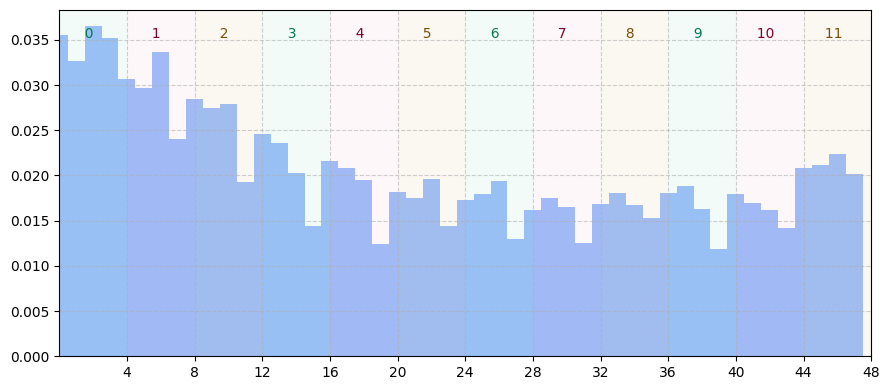

In [45]:
def visualize_weights(weights, xlabel="", ylabel="", title="", filename=""):

    # Support torch tensor / numpy array / list
    if hasattr(weights, "detach"):
        weights = weights.detach().cpu().numpy()
    else:
        weights = np.asarray(weights)

    weights = weights.reshape(-1)

    if len(weights) != 48:
        raise ValueError(f"Expected 48 weights, got {len(weights)}")

    plt.figure(figsize=(9, 4))

    # Plot all weights with the original bar style
    plt.xlim(0, 48)
    plt.xticks([4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48])

    plt.bar(
        range(len(weights)),
        weights,
        label=ylabel,
        color="#a0c0fb",
        alpha=1.0,
        width=1.00,
    )

    # Dynamic y-position for labels
    current_ylim = plt.gca().get_ylim()
    text_y_position = current_ylim[1] * 0.92

    # Reuse the original palette, cycling over the 12 groups
    fill_colors = ["#08c181", "#c10849", "#c18108"]
    text_colors = ["#057850", "#78052d", "#785005"]

    group_size = 4
    num_groups = 12
    max_index_todraw = len(weights)

    for g in range(num_groups):
        start = g * group_size
        end_axvspan = start + group_size
        end_display = end_axvspan - 1

        fill_color = fill_colors[g % len(fill_colors)]
        text_color = text_colors[g % len(text_colors)]
        alpha = 0.05 if (g % 3 != 1) else 0.03  # mimic original lighter middle style

        span_end = min(end_axvspan, max_index_todraw)
        if start < span_end:
            plt.axvspan(start, span_end, facecolor=fill_color, alpha=alpha)
            plt.text(
                (start + min(end_display, max_index_todraw - 1)) / 2,
                text_y_position,
                f"  {g}",
                horizontalalignment='center',
                fontsize=10,
                color=text_color,
                alpha=1.0,
            )

    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=12)

    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.grid(True, axis='x', which='major', linestyle='--', alpha=0.6)

    plt.tight_layout()
    if filename != "":
        plt.savefig(filename, dpi=400, bbox_inches="tight")
    plt.show()

final_weights = process_raw_weights(raw_weights_param).detach().cpu()
visualize_weights(final_weights)

In [46]:
if LoGRA_or_TracIn:
    torch.save((sim_matrix * final_weights.view(1, 1, -1).cuda()).sum(-1, keepdim=True), f"results/logra_weighted_{proj_dim}.pt")
else:
    torch.save((sim_matrix * final_weights.view(1, 1, -1).cuda()).sum(-1, keepdim=True), f"results/tracin_weighted_{proj_dim}.pt")